In [3]:
import torch
from torch import nn
from torch.nn import functional as F


from collections import OrderedDict

In [4]:

class DeepLabHeadV3Plus(nn.Module):
    def __init__(self, in_channels, low_level_channels, num_classes, aspp_dilate=[12, 24, 36]):
        super(DeepLabHeadV3Plus, self).__init__()
        self.project = nn.Sequential(
            nn.Conv2d(low_level_channels, 48, 1, bias=False),
            nn.BatchNorm2d(48),
            nn.ReLU(inplace=True),
        )

        self.aspp = ASPP(in_channels, aspp_dilate)

        self.classifier = nn.Sequential(
            nn.Conv2d(304, 256, 3, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, num_classes, 1)
        )
        self._init_weight()

    def forward(self, feature):
        low_level_feature = self.project( feature['low_level'] )
        output_feature = self.aspp(feature['out'])
        output_feature = F.interpolate(output_feature, size=low_level_feature.shape[2:], mode='bilinear', align_corners=False)
        return self.classifier( torch.cat( [ low_level_feature, output_feature ], dim=1 ) )

    def _init_weight(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight)
            elif isinstance(m, (nn.BatchNorm2d, nn.GroupNorm)):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)


class ASPPConv(nn.Sequential):
    def __init__(self, in_channels, out_channels, dilation):
        modules = [
            nn.Conv2d(in_channels, out_channels, 3, padding=dilation, dilation=dilation, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        ]
        super(ASPPConv, self).__init__(*modules)

class ASPPPooling(nn.Sequential):
    def __init__(self, in_channels, out_channels):
        super(ASPPPooling, self).__init__(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(in_channels, out_channels, 1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True))

    def forward(self, x):
        size = x.shape[-2:]
        x = super(ASPPPooling, self).forward(x)
        return F.interpolate(x, size=size, mode='bilinear', align_corners=False)

class ASPP(nn.Module):
    def __init__(self, in_channels, atrous_rates):
        super(ASPP, self).__init__()
        out_channels = 256
        modules = []
        modules.append(nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)))

        rate1, rate2, rate3 = tuple(atrous_rates)
        modules.append(ASPPConv(in_channels, out_channels, rate1))
        modules.append(ASPPConv(in_channels, out_channels, rate2))
        modules.append(ASPPConv(in_channels, out_channels, rate3))
        modules.append(ASPPPooling(in_channels, out_channels))

        self.convs = nn.ModuleList(modules)

        self.project = nn.Sequential(
            nn.Conv2d(5 * out_channels, out_channels, 1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Dropout(0.1),)

    def forward(self, x):
        res = []
        for conv in self.convs:
            res.append(conv(x))
        res = torch.cat(res, dim=1)
        return self.project(res)




In [5]:
import torch
import torch.nn as nn
try: # for torchvision<0.4
    from torchvision.models.utils import load_state_dict_from_url
except: # for torchvision>=0.4
    from torch.hub import load_state_dict_from_url


__all__ = ['ResNet', 'resnet18', 'resnet34', 'resnet50', 'resnet101',
           'resnet152', 'resnext50_32x4d', 'resnext101_32x8d',
           'wide_resnet50_2', 'wide_resnet101_2']


model_urls = {
    'resnet18': 'https://download.pytorch.org/models/resnet18-5c106cde.pth',
    'resnet34': 'https://download.pytorch.org/models/resnet34-333f7ec4.pth',
    'resnet50': 'https://download.pytorch.org/models/resnet50-19c8e357.pth',
    'resnet101': 'https://download.pytorch.org/models/resnet101-5d3b4d8f.pth',
    'resnet152': 'https://download.pytorch.org/models/resnet152-b121ed2d.pth',
    'resnext50_32x4d': 'https://download.pytorch.org/models/resnext50_32x4d-7cdf4587.pth',
    'resnext101_32x8d': 'https://download.pytorch.org/models/resnext101_32x8d-8ba56ff5.pth',
    'wide_resnet50_2': 'https://download.pytorch.org/models/wide_resnet50_2-95faca4d.pth',
    'wide_resnet101_2': 'https://download.pytorch.org/models/wide_resnet101_2-32ee1156.pth',
}


def conv3x3(in_planes, out_planes, stride=1, groups=1, dilation=1):
    """3x3 convolution with padding"""
    return nn.Conv2d(in_planes, out_planes, kernel_size=3, stride=stride,
                     padding=dilation, groups=groups, bias=False, dilation=dilation)


def conv1x1(in_planes, out_planes, stride=1):
    """1x1 convolution"""
    return nn.Conv2d(in_planes, out_planes, kernel_size=1, stride=stride, bias=False)


class BasicBlock(nn.Module):
    expansion = 1

    def __init__(self, inplanes, planes, stride=1, downsample=None, groups=1,
                 base_width=64, dilation=1, norm_layer=None):
        super(BasicBlock, self).__init__()
        if norm_layer is None:
            norm_layer = nn.BatchNorm2d
        if groups != 1 or base_width != 64:
            raise ValueError('BasicBlock only supports groups=1 and base_width=64')
        if dilation > 1:
            raise NotImplementedError("Dilation > 1 not supported in BasicBlock")
        # Both self.conv1 and self.downsample layers downsample the input when stride != 1
        self.conv1 = conv3x3(inplanes, planes, stride)
        self.bn1 = norm_layer(planes)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = conv3x3(planes, planes)
        self.bn2 = norm_layer(planes)
        self.downsample = downsample
        self.stride = stride

    def forward(self, x):
        identity = x

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)

        if self.downsample is not None:
            identity = self.downsample(x)

        out += identity
        out = self.relu(out)

        return out


class Bottleneck(nn.Module):
    expansion = 4

    def __init__(self, inplanes, planes, stride=1, downsample=None, groups=1,
                 base_width=64, dilation=1, norm_layer=None):
        super(Bottleneck, self).__init__()
        if norm_layer is None:
            norm_layer = nn.BatchNorm2d
        width = int(planes * (base_width / 64.)) * groups
        # Both self.conv2 and self.downsample layers downsample the input when stride != 1
        self.conv1 = conv1x1(inplanes, width)
        self.bn1 = norm_layer(width)
        self.conv2 = conv3x3(width, width, stride, groups, dilation)
        self.bn2 = norm_layer(width)
        self.conv3 = conv1x1(width, planes * self.expansion)
        self.bn3 = norm_layer(planes * self.expansion)
        self.relu = nn.ReLU(inplace=True)
        self.downsample = downsample
        self.stride = stride

    def forward(self, x):
        identity = x

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)
        out = self.relu(out)

        out = self.conv3(out)
        out = self.bn3(out)

        if self.downsample is not None:
            identity = self.downsample(x)

        out += identity
        out = self.relu(out)

        return out


class ResNet(nn.Module):

    def __init__(self, block, layers, num_classes=1000, zero_init_residual=False,
                 groups=1, width_per_group=64, replace_stride_with_dilation=None,
                 norm_layer=None):
        super(ResNet, self).__init__()
        if norm_layer is None:
            norm_layer = nn.BatchNorm2d
        self._norm_layer = norm_layer

        self.inplanes = 64
        self.dilation = 1
        if replace_stride_with_dilation is None:
            # each element in the tuple indicates if we should replace
            # the 2x2 stride with a dilated convolution instead
            replace_stride_with_dilation = [False, False, False]
        if len(replace_stride_with_dilation) != 3:
            raise ValueError("replace_stride_with_dilation should be None "
                             "or a 3-element tuple, got {}".format(replace_stride_with_dilation))
        self.groups = groups
        self.base_width = width_per_group
        self.conv1 = nn.Conv2d(3, self.inplanes, kernel_size=7, stride=2, padding=3,
                               bias=False)
        self.bn1 = norm_layer(self.inplanes)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        self.layer1 = self._make_layer(block, 64, layers[0])
        self.layer2 = self._make_layer(block, 128, layers[1], stride=2,
                                       dilate=replace_stride_with_dilation[0])
        self.layer3 = self._make_layer(block, 256, layers[2], stride=2,
                                       dilate=replace_stride_with_dilation[1])
        self.layer4 = self._make_layer(block, 512, layers[3], stride=2,
                                       dilate=replace_stride_with_dilation[2])
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512 * block.expansion, num_classes)

        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, (nn.BatchNorm2d, nn.GroupNorm)):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

        # Zero-initialize the last BN in each residual branch,
        # so that the residual branch starts with zeros, and each residual block behaves like an identity.
        # This improves the model by 0.2~0.3% according to https://arxiv.org/abs/1706.02677
        if zero_init_residual:
            for m in self.modules():
                if isinstance(m, Bottleneck):
                    nn.init.constant_(m.bn3.weight, 0)
                elif isinstance(m, BasicBlock):
                    nn.init.constant_(m.bn2.weight, 0)

    def _make_layer(self, block, planes, blocks, stride=1, dilate=False):
        norm_layer = self._norm_layer
        downsample = None
        previous_dilation = self.dilation
        if dilate:
            self.dilation *= stride
            stride = 1
        if stride != 1 or self.inplanes != planes * block.expansion:
            downsample = nn.Sequential(
                conv1x1(self.inplanes, planes * block.expansion, stride),
                norm_layer(planes * block.expansion),
            )

        layers = []
        layers.append(block(self.inplanes, planes, stride, downsample, self.groups,
                            self.base_width, previous_dilation, norm_layer))
        self.inplanes = planes * block.expansion
        for _ in range(1, blocks):
            layers.append(block(self.inplanes, planes, groups=self.groups,
                                base_width=self.base_width, dilation=self.dilation,
                                norm_layer=norm_layer))

        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)

        return x


def _resnet(arch, block, layers, pretrained, progress, **kwargs):
    model = ResNet(block, layers, **kwargs)
    if pretrained:
        state_dict = load_state_dict_from_url(model_urls[arch],
                                              progress=progress)
        model.load_state_dict(state_dict)
    return model


def resnet18(pretrained=False, progress=True, **kwargs):
    r"""ResNet-18 model from
    `"Deep Residual Learning for Image Recognition" <https://arxiv.org/pdf/1512.03385.pdf>`_

    Args:
        pretrained (bool): If True, returns a model pre-trained on ImageNet
        progress (bool): If True, displays a progress bar of the download to stderr
    """
    return _resnet('resnet18', BasicBlock, [2, 2, 2, 2], pretrained, progress,
                   **kwargs)


def resnet34(pretrained=False, progress=True, **kwargs):
    r"""ResNet-34 model from
    `"Deep Residual Learning for Image Recognition" <https://arxiv.org/pdf/1512.03385.pdf>`_

    Args:
        pretrained (bool): If True, returns a model pre-trained on ImageNet
        progress (bool): If True, displays a progress bar of the download to stderr
    """
    return _resnet('resnet34', BasicBlock, [3, 4, 6, 3], pretrained, progress,
                   **kwargs)


def resnet50(pretrained=False, progress=True, **kwargs):
    r"""ResNet-50 model from
    `"Deep Residual Learning for Image Recognition" <https://arxiv.org/pdf/1512.03385.pdf>`_

    Args:
        pretrained (bool): If True, returns a model pre-trained on ImageNet
        progress (bool): If True, displays a progress bar of the download to stderr
    """
    return _resnet('resnet50', Bottleneck, [3, 4, 6, 3], pretrained, progress,
                   **kwargs)


def resnet101(pretrained=False, progress=True, **kwargs):
    r"""ResNet-101 model from
    `"Deep Residual Learning for Image Recognition" <https://arxiv.org/pdf/1512.03385.pdf>`_

    Args:
        pretrained (bool): If True, returns a model pre-trained on ImageNet
        progress (bool): If True, displays a progress bar of the download to stderr
    """
    return _resnet('resnet101', Bottleneck, [3, 4, 23, 3], pretrained, progress,
                   **kwargs)


def resnet152(pretrained=False, progress=True, **kwargs):
    r"""ResNet-152 model from
    `"Deep Residual Learning for Image Recognition" <https://arxiv.org/pdf/1512.03385.pdf>`_

    Args:
        pretrained (bool): If True, returns a model pre-trained on ImageNet
        progress (bool): If True, displays a progress bar of the download to stderr
    """
    return _resnet('resnet152', Bottleneck, [3, 8, 36, 3], pretrained, progress,
                   **kwargs)


def resnext50_32x4d(pretrained=False, progress=True, **kwargs):
    r"""ResNeXt-50 32x4d model from
    `"Aggregated Residual Transformation for Deep Neural Networks" <https://arxiv.org/pdf/1611.05431.pdf>`_

    Args:
        pretrained (bool): If True, returns a model pre-trained on ImageNet
        progress (bool): If True, displays a progress bar of the download to stderr
    """
    kwargs['groups'] = 32
    kwargs['width_per_group'] = 4
    return _resnet('resnext50_32x4d', Bottleneck, [3, 4, 6, 3],
                   pretrained, progress, **kwargs)


def resnext101_32x8d(pretrained=False, progress=True, **kwargs):
    r"""ResNeXt-101 32x8d model from
    `"Aggregated Residual Transformation for Deep Neural Networks" <https://arxiv.org/pdf/1611.05431.pdf>`_

    Args:
        pretrained (bool): If True, returns a model pre-trained on ImageNet
        progress (bool): If True, displays a progress bar of the download to stderr
    """
    kwargs['groups'] = 32
    kwargs['width_per_group'] = 8
    return _resnet('resnext101_32x8d', Bottleneck, [3, 4, 23, 3],
                   pretrained, progress, **kwargs)


def wide_resnet50_2(pretrained=False, progress=True, **kwargs):
    r"""Wide ResNet-50-2 model from
    `"Wide Residual Networks" <https://arxiv.org/pdf/1605.07146.pdf>`_

    The model is the same as ResNet except for the bottleneck number of channels
    which is twice larger in every block. The number of channels in outer 1x1
    convolutions is the same, e.g. last block in ResNet-50 has 2048-512-2048
    channels, and in Wide ResNet-50-2 has 2048-1024-2048.

    Args:
        pretrained (bool): If True, returns a model pre-trained on ImageNet
        progress (bool): If True, displays a progress bar of the download to stderr
    """
    kwargs['width_per_group'] = 64 * 2
    return _resnet('wide_resnet50_2', Bottleneck, [3, 4, 6, 3],
                   pretrained, progress, **kwargs)


def wide_resnet101_2(pretrained=False, progress=True, **kwargs):
    r"""Wide ResNet-101-2 model from
    `"Wide Residual Networks" <https://arxiv.org/pdf/1605.07146.pdf>`_

    The model is the same as ResNet except for the bottleneck number of channels
    which is twice larger in every block. The number of channels in outer 1x1
    convolutions is the same, e.g. last block in ResNet-50 has 2048-512-2048
    channels, and in Wide ResNet-50-2 has 2048-1024-2048.

    Args:
        pretrained (bool): If True, returns a model pre-trained on ImageNet
        progress (bool): If True, displays a progress bar of the download to stderr
    """
    kwargs['width_per_group'] = 64 * 2
    return _resnet('wide_resnet101_2', Bottleneck, [3, 4, 23, 3],
                   pretrained, progress, **kwargs)

In [6]:

class IntermediateLayerGetter(nn.ModuleDict):
    """
    Module wrapper that returns intermediate layers from a model

    It has a strong assumption that the modules have been registered
    into the model in the same order as they are used.
    This means that one should **not** reuse the same nn.Module
    twice in the forward if you want this to work.

    Additionally, it is only able to query submodules that are directly
    assigned to the model. So if `model` is passed, `model.feature1` can
    be returned, but not `model.feature1.layer2`.

    Arguments:
        model (nn.Module): model on which we will extract the features
        return_layers (Dict[name, new_name]): a dict containing the names
            of the modules for which the activations will be returned as
            the key of the dict, and the value of the dict is the name
            of the returned activation (which the user can specify).

    Examples::

        >>> m = torchvision.models.resnet18(pretrained=True)
        >>> # extract layer1 and layer3, giving as names `feat1` and feat2`
        >>> new_m = torchvision.models._utils.IntermediateLayerGetter(m,
        >>>     {'layer1': 'feat1', 'layer3': 'feat2'})
        >>> out = new_m(torch.rand(1, 3, 224, 224))
        >>> print([(k, v.shape) for k, v in out.items()])
        >>>     [('feat1', torch.Size([1, 64, 56, 56])),
        >>>      ('feat2', torch.Size([1, 256, 14, 14]))]
    """
    def __init__(self, model, return_layers, hrnet_flag=False):
        if not set(return_layers).issubset([name for name, _ in model.named_children()]):
            raise ValueError("return_layers are not present in model")

        self.hrnet_flag = hrnet_flag

        orig_return_layers = return_layers
        return_layers = {k: v for k, v in return_layers.items()}
        layers = OrderedDict()
        for name, module in model.named_children():
            layers[name] = module
            if name in return_layers:
                del return_layers[name]
            if not return_layers:
                break

        super(IntermediateLayerGetter, self).__init__(layers)
        self.return_layers = orig_return_layers

    def forward(self, x):
        out = OrderedDict()
        for name, module in self.named_children():
            if self.hrnet_flag and name.startswith('transition'): # if using hrnet, you need to take care of transition
                if name == 'transition1': # in transition1, you need to split the module to two streams first
                    x = [trans(x) for trans in module]
                else: # all other transition is just an extra one stream split
                    x.append(module(x[-1]))
            else: # other models (ex:resnet,mobilenet) are convolutions in series.
                x = module(x)

            if name in self.return_layers:
                out_name = self.return_layers[name]
                if name == 'stage4' and self.hrnet_flag: # In HRNetV2, we upsample and concat all outputs streams together
                    output_h, output_w = x[0].size(2), x[0].size(3)  # Upsample to size of highest resolution stream
                    x1 = F.interpolate(x[1], size=(output_h, output_w), mode='bilinear', align_corners=False)
                    x2 = F.interpolate(x[2], size=(output_h, output_w), mode='bilinear', align_corners=False)
                    x3 = F.interpolate(x[3], size=(output_h, output_w), mode='bilinear', align_corners=False)
                    x = torch.cat([x[0], x1, x2, x3], dim=1)
                    out[out_name] = x
                else:
                    out[out_name] = x
        return out

class _SimpleSegmentationModel(nn.Module):
    def __init__(self, backbone, classifier):
        super(_SimpleSegmentationModel, self).__init__()
        self.backbone = backbone
        self.classifier = classifier

    def forward(self, x):
        input_shape = x.shape[-2:]
        features = self.backbone(x)
        x = self.classifier(features)
        x = F.interpolate(x, size=input_shape, mode='bilinear', align_corners=False)
        return x

class DeepLabV3(_SimpleSegmentationModel):
    """
    Implements DeepLabV3 model from
    `"Rethinking Atrous Convolution for Semantic Image Segmentation"
    <https://arxiv.org/abs/1706.05587>`_.

    Arguments:
        backbone (nn.Module): the network used to compute the features for the model.
            The backbone should return an OrderedDict[Tensor], with the key being
            "out" for the last feature map used, and "aux" if an auxiliary classifier
            is used.
        classifier (nn.Module): module that takes the "out" element returned from
            the backbone and returns a dense prediction.
        aux_classifier (nn.Module, optional): auxiliary classifier used during training
    """
    pass

def _segm_resnet(name, backbone_name, num_classes, output_stride, pretrained_backbone):

    if output_stride==8:
        replace_stride_with_dilation=[False, True, True]
        aspp_dilate = [12, 24, 36]
    else:
        replace_stride_with_dilation=[False, False, True]
        aspp_dilate = [6, 12, 18]

    backbone = resnet50( #change this to change backbone
        pretrained=pretrained_backbone,
        replace_stride_with_dilation=replace_stride_with_dilation)

    inplanes = 2048
    low_level_planes = 256

    if name=='deeplabv3plus':
        return_layers = {'layer4': 'out', 'layer1': 'low_level'}
        classifier = DeepLabHeadV3Plus(inplanes, low_level_planes, num_classes, aspp_dilate)
    '''
    elif name=='deeplabv3':
        return_layers = {'layer4': 'out'}
        classifier = DeepLabHead(inplanes , num_classes, aspp_dilate)
    '''
    backbone = IntermediateLayerGetter(backbone, return_layers=return_layers)

    model = DeepLabV3(backbone, classifier)
    return model


In [7]:
import rasterio
import numpy as np

def load_and_preprocess(path):
    with rasterio.open(path) as src:
        # Read all bands
        img = src.read()

        # Replace No-Data (example: -9999) with 0
        img[img == src.nodata] = 0

        # Robust Scaling (2nd and 98th percentile to remove outliers)
        p2, p98 = np.percentile(img, (2, 98))
        img = np.clip(img, p2, p98)
        img = (img - p2) / (p98 - p2)

    return img.astype(np.float32)


# Helper function to load raw mask data (without scaling or robust percentile clipping)
# Assumes single-channel mask where pixel values are class labels
def load_raw_mask(path):
    with rasterio.open(path) as src:
        mask_np = src.read()
        # Replace No-Data with 0 (or a specific background class ID)
        if src.nodata is not None:
            mask_np[mask_np == src.nodata] = 0

        # Recode classes 2 and 3 to 0
        #mask_np[mask_np == 2] = 0
        #mask_np[mask_np == 3] = 0

    return mask_np.astype(np.int64) # Masks are typically integer class labels

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import random
from functools import reduce
import itertools
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, datasets, models
from collections import defaultdict
import torch.nn.functional as F
import torch
import torch.optim as optim
from torch.optim import lr_scheduler
import time
import copy


def plot_img_array(img_array, ncol=3):
    # Calculate nrow, ensuring at least 1 row, and rounding up
    nrow = (len(img_array) + ncol - 1) // ncol
    if nrow == 0: # Handle empty img_array case
        return

    f, plots = plt.subplots(nrow, ncol, sharex='all', sharey='all', figsize=(ncol * 4, nrow * 4))

    # Flatten the plots array for consistent indexing across all cases
    # If plt.subplots returns a single Axes object (nrow=1, ncol=1), make it an array
    if not isinstance(plots, np.ndarray):
        plots = np.array([plots])
    else:
        plots = plots.ravel() # Flatten 2D array or keep 1D array as is

    for i in range(len(img_array)):
        plots[i].imshow(img_array[i])
        plots[i].axis('off') # Turn off axes for individual plots

    # Hide any remaining empty subplots
    for i in range(len(img_array), len(plots)):
        plots[i].axis('off')

    plt.tight_layout()
    plt.show()


def plot_side_by_side(img_arrays):
    flatten_list = reduce(lambda x,y: x+y, zip(*img_arrays))

    plot_img_array(np.array(flatten_list), ncol=len(img_arrays))


def plot_errors(results_dict, title):
    markers = itertools.cycle(('+', 'x', 'o'))

    plt.title('{}'.format(title))

    for label, result in sorted(results_dict.items()):
        plt.plot(result, marker=next(markers), label=label)
        plt.ylabel('loss')
        plt.xlabel('epoch')
        plt.legend(loc=3, bbox_to_anchor=(1, 0))

    plt.show()


def reverse_transform(inp):
    inp = inp.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    inp = (inp * 255).astype(np.uint8)

    return inp

def masks_to_colorimg(masks):
    # Corrected to 2 colors to match the 2 combined classes
    colors = np.asarray([(0, 255, 0), (0, 0, 255)]) # Green for class 0, Blue for class 1

    colorimg = np.ones((masks.shape[1], masks.shape[2], 3), dtype=np.float32) * 255
    channels, height, width = masks.shape

    for y in range(height):
        for x in range(width):
            selected_colors = colors[masks[:,y,x] > 0.35] # Threshold for displaying class values

            if len(selected_colors) > 0:
                colorimg[y,x,:] = np.mean(selected_colors, axis=0)

    return colorimg.astype(np.uint8)


In [9]:
from torch.utils.data import Dataset
from PIL import Image
import torch
from torchvision import transforms
import rasterio
import numpy as np

class TrainingDataset(Dataset):
    def __init__(self, image_paths, label_paths, transform=None, num_classes=1): # Changed num_classes to 1
        self.image_paths = image_paths
        self.label_paths = label_paths
        self.transform = transform # This transform is for images
        self.num_classes = num_classes # Will always be 1 for binary segmentation
        print("using the one with binary segmentation")

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, index):
        # Load image as NumPy array (C, H, W, float32) using the provided function
        image_np = load_and_preprocess(self.image_paths[index])

        # Load mask as NumPy array (1, H, W, int64) using the new helper function
        mask_np_raw = load_raw_mask(self.label_paths[index])

        # Apply class remapping: combine classes 2 and 3 into class 1, other non-zero to 1, all others to 0
        # Now we want a binary mask: 1 for road, 0 for background
        # Original values: 0 (background), 1 (road), 2 (building), 3 (vehicle)
        # We want: 1 (road), 0 (all others)
        mask_np_raw = np.where(mask_np_raw == 1, 1, 0) # Only class 1 (road) becomes 1, everything else becomes 0

        # Convert image_np (C, H, W) to a PIL Image (H, W, C) for torchvision transforms
        # which expect PIL Image for operations like Resize
        if image_np.shape[0] == 3: # Assuming RGB
            # Multiply by 255 and convert to uint8 before creating PIL Image
            image_pil = Image.fromarray((image_np.transpose(1, 2, 0) * 255).astype(np.uint8))
        elif image_np.shape[0] == 1: # Assuming grayscale
            image_pil = Image.fromarray((image_np.squeeze(0) * 255).astype(np.uint8))
        else:
            raise ValueError(f"Unsupported image channel count: {image_np.shape[0]} for PIL conversion")

        # Apply the image transform (includes Resize, ToTensor, Normalize)
        if self.transform:
            image_tensor = self.transform(image_pil)
        else:
            # If no transform is provided, at least convert to tensor
            image_tensor = transforms.ToTensor()(image_pil)

        # Determine the target size for the mask from the transformed image
        target_size = image_tensor.shape[-2:] # Get (H, W) from the image tensor

        # Convert raw mask (1, H, W) to PyTorch Tensor (float32 for BCEWithLogitsLoss)
        mask_tensor = torch.from_numpy(mask_np_raw).float()

        # Resize the mask using nearest neighbor interpolation
        # Ensure mask_tensor is (C, H, W) for Resize, then (1, H, W) float
        mask_resized = transforms.Resize(target_size, interpolation=transforms.InterpolationMode.NEAREST)(
            mask_tensor
        )

        # For binary segmentation, the target should be a single-channel float tensor
        # (N, 1, H, W). Our mask_resized is (1, H, W) so it's ready.
        return image_tensor, mask_resized

print("TrainingDataset class defined for binary segmentation.")

TrainingDataset class defined for binary segmentation.


In [19]:
import os
import glob
import random
from sklearn.model_selection import train_test_split
from torchvision import transforms
from torch.utils.data import DataLoader
import torch
import numpy as np

def get_data_loaders(batch_size=4, subset_size=None, undersampling_ratio=0.0, minority_class_threshold=0.2, path = '/Users/yujiewu/SP/bogota-roads-filtered'):
    base_path = path
    image_dir = os.path.join(base_path, 'images')
    label_dir = os.path.join(base_path, 'labels')

    all_image_paths = sorted(glob.glob(os.path.join(image_dir, '*.tif')))
    all_label_paths = sorted(glob.glob(os.path.join(label_dir, '*.tif')))

    if len(all_image_paths) != len(all_label_paths):
        raise ValueError("Mismatch between number of images and labels.")

    # Pair image and label paths
    all_pairs = list(zip(all_image_paths, all_label_paths))

    # Split all pairs into training and validation sets
    train_pairs, val_pairs = train_test_split(all_pairs, test_size=0.2, random_state=42)

    # --- Undersampling for the training set --- (not used, saved on google colab)
    
    if subset_size is not None:
        final_train_pairs = train_pairs[:subset_size]#final_train_pairs[:subset_size]
        val_pairs = val_pairs[:subset_size // 4] # Keep validation subset smaller if train is subsetted
    #else:
    #  val_pairs = val_pairs[:len(final_train_pairs) // 4]
    train_image_paths = [p[0] for p in train_pairs]#final_train_pairs]
    train_label_paths = [p[1] for p in train_pairs]#final_train_pairs]

    val_image_paths = [p[0] for p in val_pairs]
    val_label_paths = [p[1] for p in val_pairs]

    print(f"Training images (using pre-undersampled drive): {len(train_image_paths)}")
    print(f"Validation images: {len(val_image_paths)}")

    # Define image transformations
    mean = [0.485, 0.456, 0.406]
    std = [0.229, 0.224, 0.225]
    image_size = (256, 256) # Define target image size, further reduced for faster verification
    #print(f"get_data_loaders: Setting image_size to {image_size}")

    train_transform = transforms.Compose([
        transforms.Resize(image_size),
        #transforms.RandomHorizontalFlip(),
        #transforms.RandomVerticalFlip(),
        #transforms.RandomRotation(degrees=10),
        transforms.ToTensor(),
        transforms.Normalize(mean=mean, std=std)
    ])

    val_transform = transforms.Compose([
        transforms.Resize(image_size),
        transforms.ToTensor(),
        transforms.Normalize(mean=mean, std=std)
    ])

    train_dataset = TrainingDataset(
        image_paths=train_image_paths,
        label_paths=train_label_paths,
        transform=train_transform
    )

    val_dataset = TrainingDataset(
        image_paths=val_image_paths,
        label_paths=val_label_paths,
        transform=val_transform
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=0
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=0
    )

    return {'train': train_loader, 'val': val_loader}

print("Function `get_data_loaders` defined with undersampling capability.")


Function `get_data_loaders` defined with undersampling capability.


In [11]:
def dice_loss(pred, target, smooth=1.):
    pred = pred.contiguous()
    target = target.contiguous()

    intersection = (pred * target).sum(dim=2).sum(dim=2)

    loss = (1 - ((2. * intersection + smooth) / (pred.sum(dim=2).sum(dim=2) + target.sum(dim=2).sum(dim=2) + smooth)))

    return loss


def calc_loss(pred, target, metrics, bce_weight=0.5, pos_weight=None):
    # Ensure pos_weight is on the correct device if provided
    if pos_weight is not None:
        pos_weight = pos_weight.to(pred.device)
        bce = F.binary_cross_entropy_with_logits(pred, target, pos_weight=pos_weight)
    else:
        bce = F.binary_cross_entropy_with_logits(pred, target)

    # Apply sigmoid for Dice loss calculation
    pred_sigmoid = torch.sigmoid(pred)
    # dice_loss returns a tensor of shape (N, 1) where each element is (1 - Dice_score)
    dice_per_sample = dice_loss(pred_sigmoid, target)

    # For Dice loss, typically mean over samples is taken.
    weighted_dice = dice_per_sample.mean()

    loss = bce * bce_weight + weighted_dice * (1 - bce_weight)

    metrics['bce'] += bce.data.cpu().numpy() * target.size(0)
    metrics['dice'] += weighted_dice.data.cpu().numpy() * target.size(0)
    metrics['loss'] += loss.data.cpu().numpy() * target.size(0)

    return loss


def print_metrics(metrics, epoch_samples, phase):
    outputs = []
    for k in metrics.keys():
        outputs.append("{}: {:4f}".format(k, metrics[k] / epoch_samples))

    print("{}: {}".format(phase, ", ".join(outputs)))


def train_model(model, optimizer, scheduler, num_epochs=25, subset_size=None, pos_weight=None):
    dataloaders = get_data_loaders(subset_size=subset_size) # Passed subset_size to get_data_loaders
    device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
    best_model_wts = copy.deepcopy(model.state_dict())
    best_loss = 1e10

    # Initialize dictionaries to store metrics for plotting
    history = defaultdict(list)

    for epoch in range(num_epochs):
        print('Epoch {}/{}'.format(epoch, num_epochs - 1))
        print('-' * 10)

        since = time.time()

        # Each epoch has a training and validation phase
        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()  # Set model to training mode
            else:
                model.eval()  # Set model to evaluate mode

            metrics = defaultdict(float)
            epoch_samples = 0

            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)

                # zero the parameter gradients
                optimizer.zero_grad()

                # forward
                # track history if only in train
                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    loss = calc_loss(outputs, labels, metrics, pos_weight=pos_weight) # Pass pos_weight

                    # backward + optimize only if in training phase
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()
                        # Move scheduler.step() after optimizer.step()
                        scheduler.step()

                # statistics
                epoch_samples += inputs.size(0)

            print_metrics(metrics, epoch_samples, phase)
            epoch_loss = metrics['loss'] / epoch_samples
            epoch_bce = metrics['bce'] / epoch_samples
            epoch_dice = metrics['dice'] / epoch_samples

            # Store metrics in history
            history[f'{phase}_loss'].append(epoch_loss)
            history[f'{phase}_bce'].append(epoch_bce)
            history[f'{phase}_dice'].append(epoch_dice)

            # deep copy the model
            if phase == 'val' and epoch_loss < best_loss:
                print("saving best model")
                best_loss = epoch_loss
                best_model_wts = copy.deepcopy(model.state_dict())

        time_elapsed = time.time() - since
        print('{:.0f}m {:.0f}s'.format(time_elapsed // 60, time_elapsed % 60))

    print('Best val loss: {:4f}'.format(best_loss))

    # load best model weights
    model.load_state_dict(best_model_wts)
    return model, history

In [25]:
epochs = 25
#1 epoch is 3 minutes on T4 GPU
num_class = 1
output_stride = 8
pretrained_backbone = True
name = 'deeplabv3plus'
backbone_name = 'resnet50'

# Define the device
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

model = _segm_resnet(name, backbone_name, num_class, output_stride, pretrained_backbone)
model.to(device) # Move model to the correct device

# Get the dictionary of dataloaders
dataloaders = get_data_loaders(batch_size=8)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
# Note: No scheduler defined here, matching the original intent of the loop. If scheduler is needed, uncomment and define.
# scheduler = lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1) # Example scheduler

history = defaultdict(list)

for epoch in range(epochs):
    print('Epoch {}/{}'.format(epoch, epochs - 1))
    print('-' * 10)

    model.train() # Set model to training mode
    total_loss = 0
    metrics = defaultdict(float) # Initialize metrics for calc_loss
    epoch_samples = 0

    since = time.time()
    for phase in ['train', 'val']:
        if phase == 'train':
            model.train()  # Set model to training mode
        else:
            model.eval()  # Set model to evaluate mode

        for images, masks in dataloaders[phase]: # Correctly iterate over the training DataLoader
            images = images.to(device)
            masks = masks.to(device)

            optimizer.zero_grad()

            preds = model(images)

            # Use calc_loss from previous cell
            loss = calc_loss(preds, masks, metrics) # calc_loss also updates metrics
            
            if phase == 'train':
                loss.backward()
                optimizer.step()

            total_loss += loss.item() * images.size(0) # Accumulate weighted loss
            epoch_samples += images.size(0)

        history[f'{phase}_loss'].append(total_loss/epoch_samples)

    # Print metrics for the training phase after each epoch
    print_metrics(metrics, epoch_samples, 'train')
    print(f"Epoch {epoch+1}, Average Loss: {total_loss/epoch_samples:.4f}")
    time_elapsed = time.time() - since
    print('{:.0f}m {:.0f}s'.format(time_elapsed // 60, time_elapsed % 60))wel

# Optional: Add validation phase if desired, similar to train_model function

print("Training complete.")

Training images (using pre-undersampled drive): 730
Validation images: 183
using the one with binary segmentation
using the one with binary segmentation
Epoch 0/24
----------
train: bce: 0.347022, dice: 0.302895, loss: 0.324958
Epoch 1, Average Loss: 0.3250
Epoch 1/24
----------
train: bce: 0.259583, dice: 0.223463, loss: 0.241523
Epoch 2, Average Loss: 0.2415
Epoch 2/24
----------
train: bce: 0.222635, dice: 0.191213, loss: 0.206924
Epoch 3, Average Loss: 0.2069
Epoch 3/24
----------
train: bce: 0.195590, dice: 0.161349, loss: 0.178470
Epoch 4, Average Loss: 0.1785
Epoch 4/24
----------
train: bce: 0.180145, dice: 0.152823, loss: 0.166484
Epoch 5, Average Loss: 0.1665
Epoch 5/24
----------
train: bce: 0.166952, dice: 0.139386, loss: 0.153169
Epoch 6, Average Loss: 0.1532
Epoch 6/24
----------
train: bce: 0.148043, dice: 0.124437, loss: 0.136240
Epoch 7, Average Loss: 0.1362
Epoch 7/24
----------
train: bce: 0.164140, dice: 0.136066, loss: 0.150103
Epoch 8, Average Loss: 0.1501
Epoch 8

/var/folders/qm/2xjt0q2x33z9bn69ybd177z80000gp/T/ipykernel_87942/1557085343.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc=3, bbox_to_anchor=(1, 0))


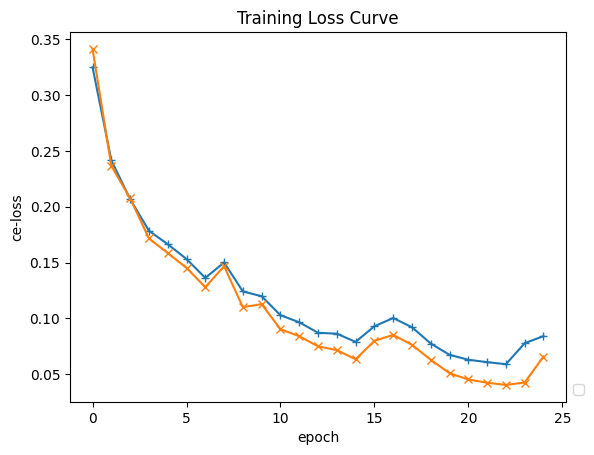

In [26]:
# Plot the learning curves
#plot_errors(history['loss'], title=)
markers = itertools.cycle(('+', 'x', 'o'))

plt.title('{}'.format('Training Loss Curve'))

#for label, result in sorted(results_dict.items()):
plt.plot(history['val_loss'], marker=next(markers))
plt.plot(history['train_loss'], marker=next(markers))
plt.ylabel('ce-loss')
plt.xlabel('epoch')
plt.legend(loc=3, bbox_to_anchor=(1, 0))

plt.show()

Training images (using pre-undersampled drive): 730
Validation images: 183
using the one with binary segmentation
using the one with binary segmentation
torch.Size([1, 3, 256, 256])


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0000001].


tensor([7.8914e-09, 7.9046e-09, 7.9178e-09,  ..., 1.0000e+00, 1.0000e+00,
        1.0000e+00], device='mps:0')
(1, 1, 256, 256)


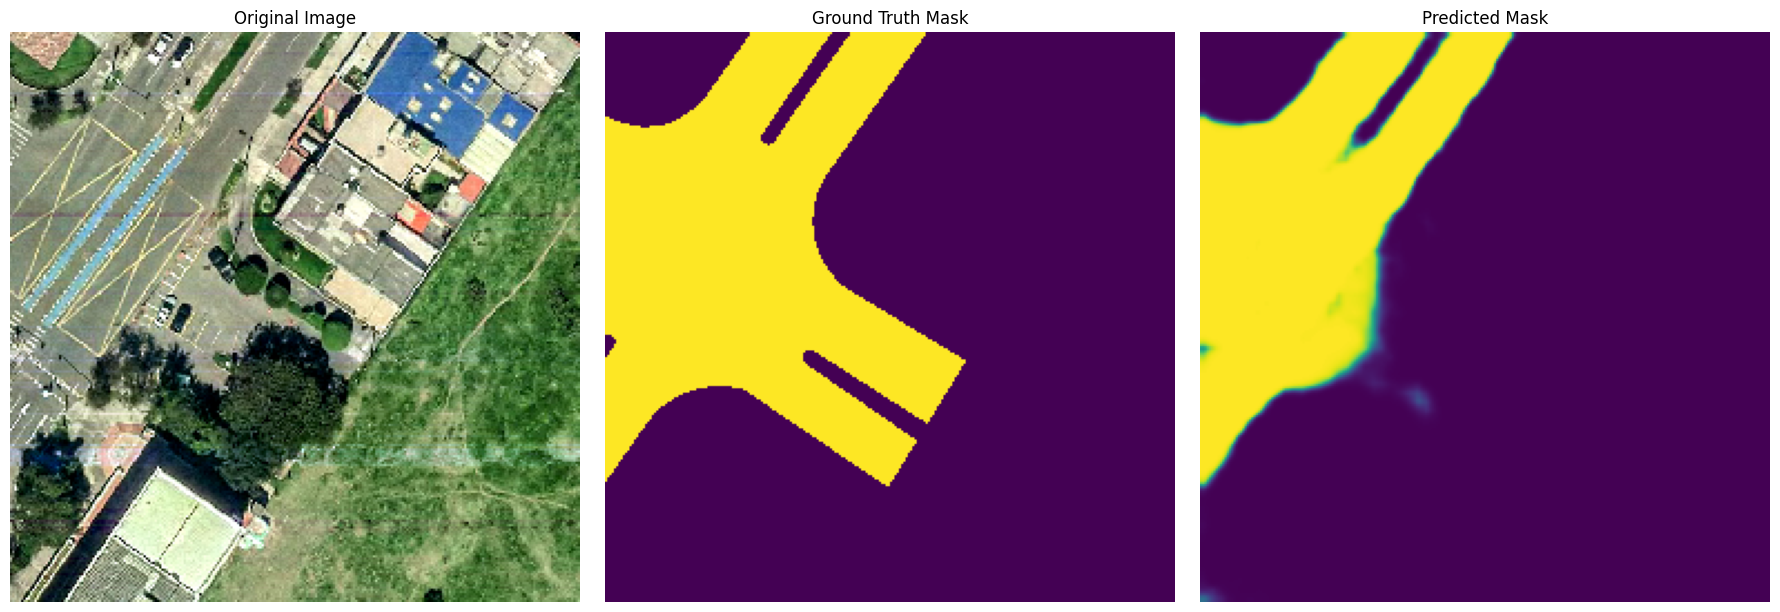

In [39]:
from sklearn.preprocessing import MinMaxScaler

num_class = 1

dataloader = get_data_loaders(batch_size=1)
# Get a sample from the validation dataset
val_dataset = dataloader['val']

data_iter = iter(val_dataset)
first_batch = next(data_iter)
inputs, labels = first_batch

idx = 0
print(inputs.shape)
# Retrieve the original image and label paths for better visualization reference
original_image_path = inputs[idx]
original_label_path = labels[idx]

# Load and preprocess the original image for display (without normalization/tensor conversion)
# The `image_tensor` is already normalized and ready for the model.
# We need the original, denormalized image for visual comparison.
original_image_display = np.transpose(inputs[idx], (1, 2, 0)).numpy()
scaler = MinMaxScaler()

# Fit and transform the data
#display_channels = []
original_image_display = [scaler.fit_transform(original_image_display[x]) for x in range(original_image_display.shape[0])]

# Move image tensor to the correct device for inference
#inputs = inputs.unsqueeze(0).to(device) # Add batch dimension
inputs = inputs.to(device)

model.eval()
with torch.no_grad():
    outputs = model(inputs)
    logits = F.sigmoid(outputs)

# Resize logits to the original label size (from the dataset item) for comparison
# and then take argmax to get class predictions
predicted_mask_tensor = torch.nn.functional.interpolate(
    logits,
    size=labels.shape[-2:], # target size is H, W of the ground truth label
    mode="bilinear",
    align_corners=False
)

print(predicted_mask_tensor.unique())
predicted_mask_tensor = predicted_mask_tensor.squeeze(0).cpu() # Remove batch dimension and move to CPU
predicted_mask_tensor = predicted_mask_tensor.squeeze(0).cpu() # Remove batch dimension and move to CPU
predicted_mask_np = predicted_mask_tensor.cpu().numpy()

# Ground truth mask (from the dataset item, already preprocessed and resized)
# Add a channel dimension for masks_to_colorimg to work correctly (expects C, H, W)
ground_truth_mask_np = labels.cpu().numpy()

print(ground_truth_mask_np.shape)
# Convert masks to color images using the defined function
colored_ground_truth = np.transpose(ground_truth_mask_np[0], (1, 2, 0))
colored_prediction = predicted_mask_np#.reshape(1, *predicted_mask_np.shape) # dont Reshape to (1, H, W)

# Plot the original image, ground truth, and prediction
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(original_image_display)
axes[0].set_title('Original Image')
axes[0].axis('off')

axes[1].imshow(colored_ground_truth)
axes[1].set_title('Ground Truth Mask')
axes[1].axis('off')

axes[2].imshow(colored_prediction)
axes[2].set_title('Predicted Mask')
axes[2].axis('off')

plt.tight_layout()
plt.show()

In [40]:
import torch
import numpy as np

class SegmentationMetrics:
    """
    Accumulates a confusion matrix over the full val set,
    then computes per-class and mean IoU + F1.
    """
    def __init__(self, num_classes: int, class_names: list[str], ignore_index: int = 255):
        self.num_classes = num_classes
        self.class_names = class_names
        self.ignore_index = ignore_index
        self.reset()

    def reset(self):
        self.confusion_matrix = np.zeros((self.num_classes, self.num_classes), dtype=np.int64)

    def update(self, preds: torch.Tensor, targets: torch.Tensor):
        """
        preds:   (B, H, W) — argmax class indices
        targets: (B, H, W) — ground truth class indices
        """
        preds = preds.cpu().numpy().flatten()
        targets = targets.cpu().numpy().flatten()

        # Mask out ignored pixels
        mask = targets != self.ignore_index
        preds, targets = preds[mask], targets[mask]

        # Accumulate into confusion matrix
        indices = self.num_classes * targets + preds
        counts = np.bincount(indices, minlength=self.num_classes ** 2)
        self.confusion_matrix += counts.reshape(self.num_classes, self.num_classes)

    def compute(self) -> dict:
        cm = self.confusion_matrix  # shape: (C, C)

        # Per-class IoU
        tp = np.diag(cm)                          # true positives per class
        fp = cm.sum(axis=0) - tp                  # false positives
        fn = cm.sum(axis=1) - tp                  # false negatives

        iou = tp / (tp + fp + fn + 1e-6)

        # Per-class F1
        precision = tp / (tp + fp + 1e-6)
        recall    = tp / (tp + fn + 1e-6)
        f1 = 2 * precision * recall / (precision + recall + 1e-6)

        results = {
            "per_class_iou":  dict(zip(self.class_names, iou)),
            "per_class_f1":   dict(zip(self.class_names, f1)),
            "miou":           float(np.mean(iou)),
            "mean_f1":        float(np.mean(f1)),
        }
        return results
    


dataloader = get_data_loaders()
# Get a sample from the validation dataset
val_dataset = dataloader['val']
metrics_calculator = SegmentationMetrics(num_classes=2, class_names=["background", "building"], ignore_index=255)
#iterate through entire val dataset and calculate mIoU for each class and mean IoU
ious_per_class = []
mean_ious = []
for inputs, labels in val_dataset:
    inputs = inputs.to(device)
    labels = labels.to(device)

    with torch.no_grad():
        outputs = model(inputs)
        logits = F.sigmoid(outputs)

    predicted_mask_tensor = torch.nn.functional.interpolate(
        logits,
        size=labels.shape[-2:], # target size is H, W of the ground truth label
        mode="bilinear",
        align_corners=False
    )

    threshold = 0.5
    building_prob = predicted_mask_tensor[:, 0, :, :]          # (B, H, W)
    predicted_mask = (building_prob >= threshold).long() # (B, H, W), values 0 or 1

    #print(f"Predicted mask shape: {predicted_mask_tensor.shape}, Labels shape: {labels.shape}")
    #print(f"Unique values in predicted mask: {torch.unique(predicted_mask)}")
    #print(f"Unique values in labels: {torch.unique(labels)}")

    # Update IoU metrics
    #print(f"Updating IoU metrics for batch with shape: {predicted_mask_tensor.shape} and labels shape: {labels.to(torch.int64).squeeze(1).shape}")
    #print(f"Unique values in labels: {torch.unique(labels)}")
    metrics_calculator.update(predicted_mask.cpu(), labels.cpu().to(torch.int64).squeeze(1)) # Squeeze to (B, H, W) and ensure labels are int64 for confusion matrix indexing

results = metrics_calculator.compute()
print("Per-class IoU:", results["per_class_iou"])
print("Per-class F1:", results["per_class_f1"])
print("Mean IoU:", results["miou"])
print("Mean F1:", results["mean_f1"])

Training images (using pre-undersampled drive): 730
Validation images: 183
using the one with binary segmentation
using the one with binary segmentation
Per-class IoU: {'background': np.float64(0.9232415991242005), 'building': np.float64(0.8283182841818747)}
Per-class F1: {'background': np.float64(0.960088549253585), 'building': np.float64(0.9060980625040659)}
Mean IoU: 0.8757799416530376
Mean F1: 0.9330933058788254
